In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import os
import soundfile as sf
from scipy import signal

In [ ]:
# Template to use: /home/super/data/music/templates/Streptopelia_semitorquata_100465.mp3
# Clip to use: /home/super/data/music/Liked Sounds/Location A Sand Forrest/Zoom_F3/030525_003_20250503_174500.wav

def compute_mel_spectrogram(y, sr, n_mels=128, hop_length=512):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=hop_length)
    S_dB = librosa.power_to_db(S, ref=np.max)
    return S_dB

def generate_specgram(SIGNAL, SAMPLE_RATE):
    """
    Generates a magnitude stft spectrogram normalized [0,1] for the sake of template matching
    SIGNAL (ndarray)
        - Audio signal of which the stft is performed
    SAMPLE_RATE (int)
        - rate at which the audio signal was sampled at
    returns:
        - 2D numpy array representing the stft of the signal using a window length of 1024 and 50% overlap
    """
    assert isinstance(SIGNAL, np.ndarray)
    assert isinstance(SAMPLE_RATE, int)
    assert SAMPLE_RATE > 0

    window_len = 1024
    noverlap = 512
    nsperseg = 1024
    f, t, SIGNAL_stft = signal.stft(SIGNAL, fs=SAMPLE_RATE, window=np.hanning(window_len), noverlap=noverlap, nperseg=nsperseg)
    SIGNAL_stft_mag = np.abs(SIGNAL_stft)
    output = SIGNAL_stft_mag/np.max(SIGNAL_stft_mag)
    return output

In [3]:
CLIP_PATH = "/home/super/data/music/Liked Sounds/Location A Sand Forrest/Zoom_F3/030525_003_20250503_174500.wav"
TEMPLATE_PATH = "/home/super/data/music/templates/Streptopelia_semitorquata_100465.mp3"

y, sr = librosa.load(TEMPLATE_PATH, sr=None)
template_spectrogram = compute_mel_spectrogram(y, sr)
template_db = librosa.amplitude_to_db(np.abs(template_spectrogram), ref=np.max)

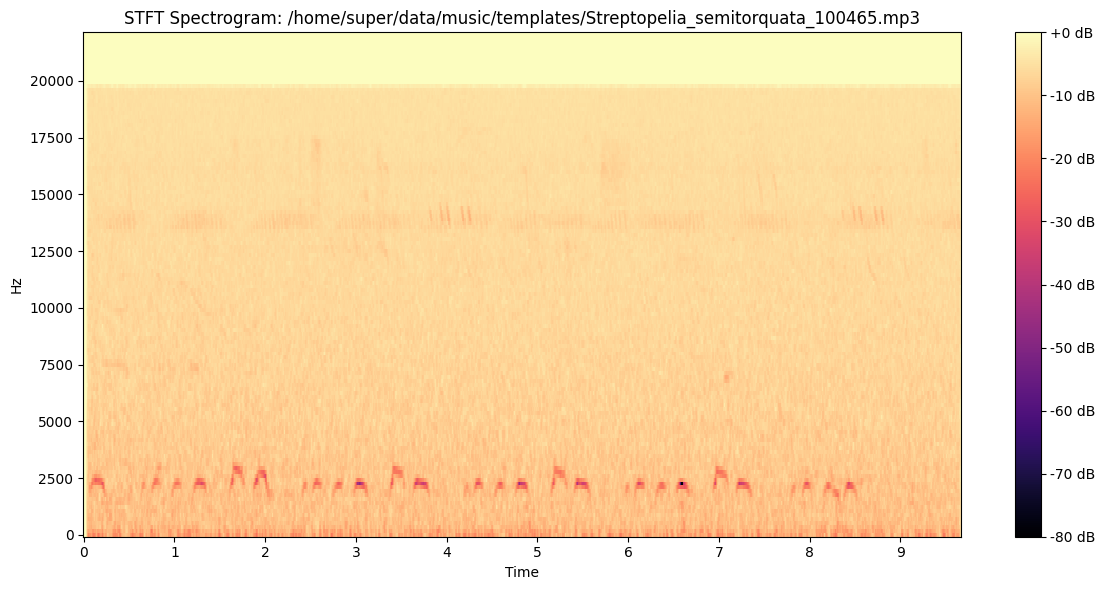

In [4]:
plt.figure(figsize=(12, 6))
librosa.display.specshow(template_db, sr=sr, hop_length=512, x_axis='time', y_axis='linear')
plt.colorbar(format="%+2.0f dB")
plt.title(f"STFT Spectrogram: {TEMPLATE_PATH}")
plt.tight_layout()
plt.show()

In [5]:
def spectrogram_to_image(S_dB):
    img = (S_dB - S_dB.min()) / (S_dB.max() - S_dB.min())
    img = (img * 255).astype(np.uint8)
    return img

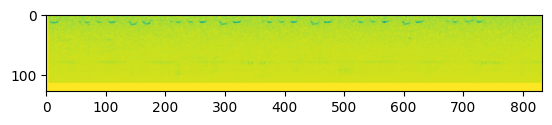

In [6]:
img = spectrogram_to_image(template_db)

plt.imshow(img)
plt.show()

Match score: 0.6666
Best match location: (8001, 0)


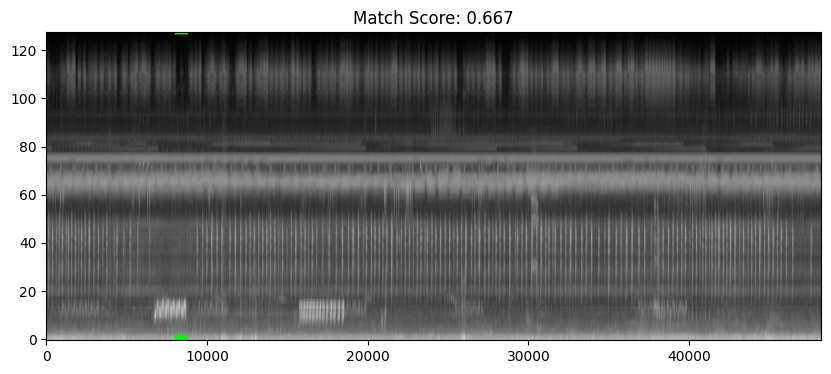

In [7]:
CLIP_PATH = "/home/super/data/music/Liked Sounds/Location A Sand Forrest/Zoom_F3/030525_003_20250503_174500.wav"
TEMPLATE_PATH = "/home/super/data/music/templates/Streptopelia_semitorquata_100465.mp3"

y_clip, sr_clip = librosa.load(CLIP_PATH, sr=None)
y_template, sr_template = librosa.load(TEMPLATE_PATH, sr=None)

clip_spec = compute_mel_spectrogram(y_clip, sr_clip)
template_spec = compute_mel_spectrogram(y_template, sr_template)

clip_img = spectrogram_to_image(clip_spec)
template_img = spectrogram_to_image(template_spec)

res = cv.matchTemplate(clip_img, template_img, cv.TM_CCOEFF_NORMED)
min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

print(f"Match score: {max_val:.4f}")
print(f"Best match location: {max_loc}")

top_left = max_loc
h, w = template_img.shape
bottom_right = (top_left[0] + w, top_left[1] + h)

vis = cv.cvtColor(clip_img, cv.COLOR_GRAY2BGR)
cv.rectangle(vis, top_left, bottom_right, (0, 255, 0), 2)

plt.figure(figsize=(10, 4))
plt.imshow(vis, aspect='auto', origin='lower', cmap='gray')
plt.title(f"Match Score: {max_val:.3f}")
plt.show()

Found 17164 matches above threshold 0.6

Kept 289 non-overlapping matches above threshold 0.6

Match at 42.67 sec (Score: 0.667)
Match at 42.40 sec (Score: 0.664)
Match at 43.06 sec (Score: 0.662)
Match at 41.69 sec (Score: 0.661)
Match at 84.40 sec (Score: 0.660)
Match at 41.38 sec (Score: 0.660)
Match at 41.96 sec (Score: 0.660)
Match at 43.46 sec (Score: 0.660)
Match at 84.98 sec (Score: 0.659)
Match at 86.33 sec (Score: 0.658)
Match at 41.11 sec (Score: 0.657)
Match at 85.75 sec (Score: 0.657)
Match at 86.04 sec (Score: 0.656)
Match at 84.12 sec (Score: 0.656)
Match at 84.67 sec (Score: 0.655)
Match at 86.66 sec (Score: 0.655)
Match at 85.25 sec (Score: 0.655)
Match at 88.03 sec (Score: 0.654)
Match at 43.80 sec (Score: 0.653)
Match at 86.94 sec (Score: 0.653)
Match at 40.81 sec (Score: 0.652)
Match at 87.76 sec (Score: 0.652)
Match at 83.85 sec (Score: 0.651)
Match at 87.45 sec (Score: 0.651)
Match at 88.31 sec (Score: 0.648)
Match at 40.36 sec (Score: 0.648)
Match at 88.58 sec (S

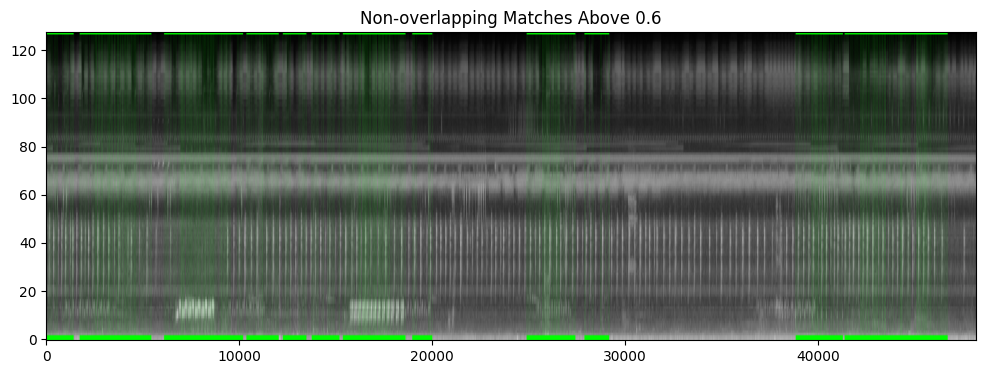

In [12]:
THRESHOLD = 0.6
SUPPRESSION_DISTANCE = 50

locations = np.where(res >= THRESHOLD)
matches = []
for pt in zip(*locations[::-1]):
    x, y = pt
    score = res[y, x]
    matches.append((y, x, score))

matches.sort(key=lambda x: x[2], reverse=True)

print(f"Found {len(matches)} matches above threshold {THRESHOLD}\n")

selected = []
for y, x, score in matches:
    if all(abs(x - xc) > SUPPRESSION_DISTANCE for _, xc, _ in selected):
        selected.append((y, x, score))

print(f"Kept {len(selected)} non-overlapping matches above threshold {THRESHOLD}\n")

seconds_per_col = 512 / sr_clip

plt.figure(figsize=(12, 4))
vis = cv.cvtColor(clip_img, cv.COLOR_GRAY2BGR)

for y, x, score in selected:
    top_left = (x, y)
    bottom_right = (x + template_img.shape[1], y + template_img.shape[0])
    cv.rectangle(vis, top_left, bottom_right, (0, 255, 0), 2)

    timestamp = x * seconds_per_col
    print(f"Match at {timestamp:.2f} sec (Score: {score:.3f})")

plt.imshow(vis, aspect='auto', origin='lower', cmap='gray')
plt.title(f"Non-overlapping Matches Above {THRESHOLD}")
plt.show()

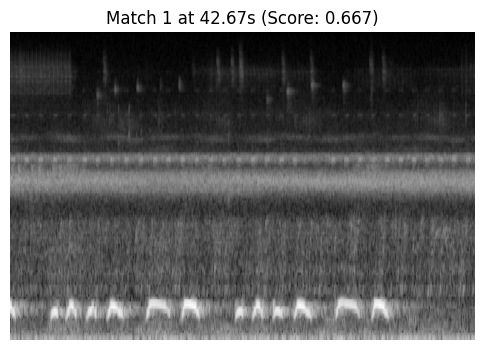

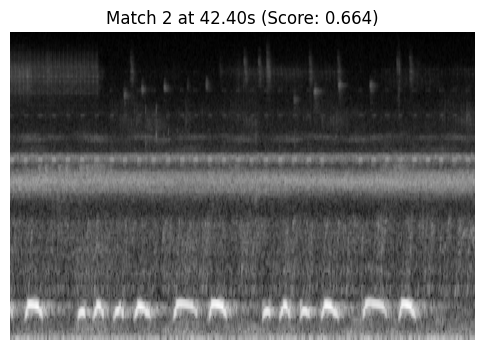

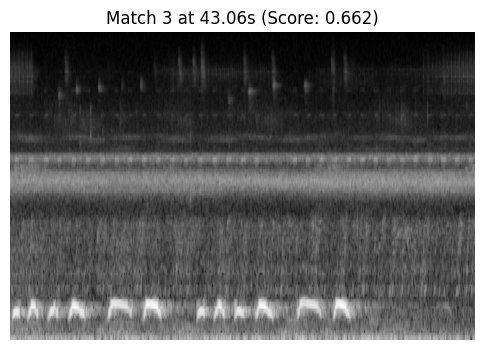

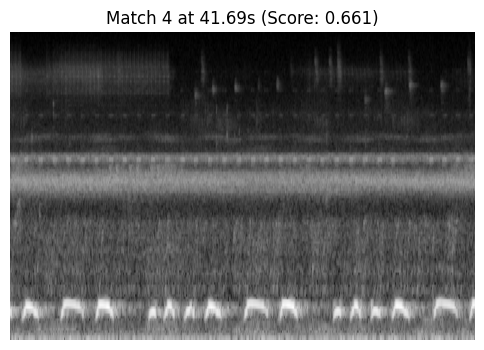

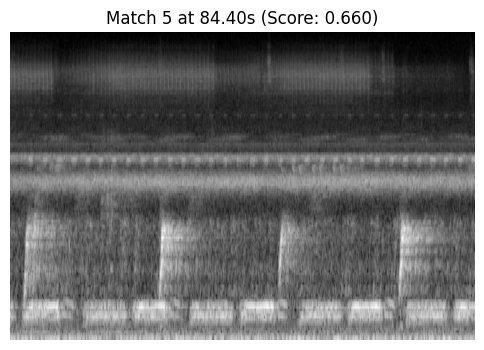

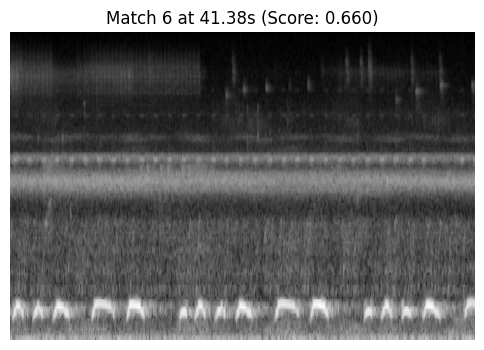

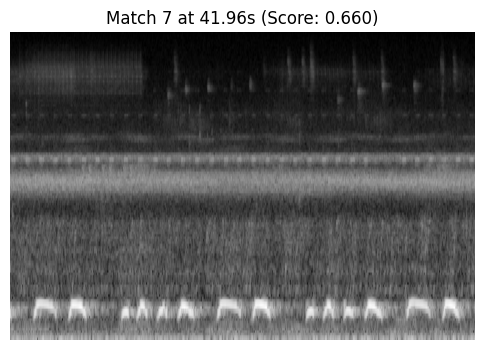

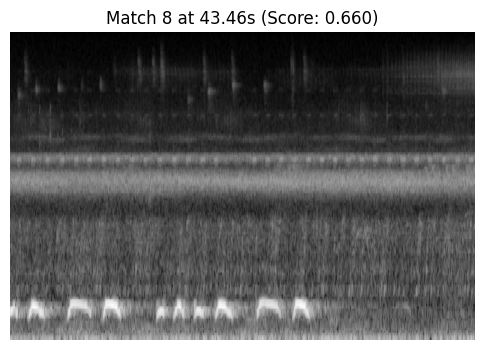

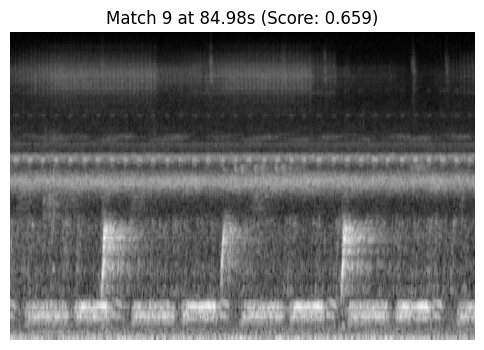

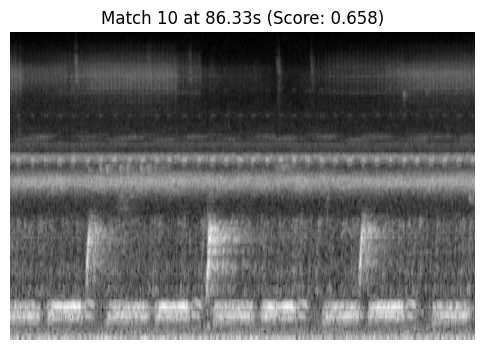

In [10]:
top_matches = selected[:10]
margin = 20

for idx, (y, x, score) in enumerate(top_matches, 1):
    x1 = max(0, x - margin)
    x2 = min(clip_img.shape[1], x + template_img.shape[1] + margin)
    y1 = max(0, y - margin)
    y2 = min(clip_img.shape[0], y + template_img.shape[0] + margin)

    zoom_region = clip_img[y1:y2, x1:x2]

    plt.figure(figsize=(6, 4))
    plt.imshow(zoom_region, aspect='auto', origin='lower', cmap='gray')
    timestamp = x * seconds_per_col
    plt.title(f"Match {idx} at {timestamp:.2f}s (Score: {score:.3f})")
    plt.axis('off')
    plt.show()

# top_matches = selected[:10]
# margin = 20

# for idx, (y, x, score) in enumerate(top_matches, 1):
#     x1 = max(0, x - margin)
#     x2 = min(clip_img.shape[1], x + template_img.shape[1] + margin)
#     y1 = max(0, y - margin)
#     y2 = min(clip_img.shape[0], y + template_img.shape[0] + margin)

#     zoom_region = clip_img[y1:y2, x1:x2]

#     times = np.arange(x1, x2) * (512 / sr_clip)

#     plt.figure(figsize=(6, 4))
#     librosa.display.specshow(
#         zoom_region,
#         sr=sr_clip,
#         hop_length=512,
#         x_axis='time',
#         y_axis='mel',
#         fmax=sr_clip // 2
#     )
#     plt.title(f"Match {idx} at {x * seconds_per_col:.2f}s (Score: {score:.3f})")
#     plt.colorbar(format='%+2.0f dB')
#     plt.tight_layout()
#     plt.show()

In [ ]:
clips = "/home/super/data/music/Location A (Sand Forrest)/A Zoom F3_03-05-25"

for clip in os.listdir(clips):
    print(f"Processing clip: {clip}")
    if clip.lower().endswith('.wav'):
        clip_path = os.path.join(clips, clip)
        
        y_clip, sr_clip = fast_audio_load(clip_path, target_sr=22050)
        print(f"Loaded clip: {clip} (duration: {len(y_clip)/sr_clip:.1f}s)")
        
        clip_spec = compute_mel_spectrogram(y_clip, sr_clip)
        print(f"Clip shape: {clip_spec.shape}")
        clip_img = spectrogram_to_image(clip_spec)

        res = cv.matchTemplate(clip_img, template_img, cv.TM_CCOEFF_NORMED)
        print(f"Performed template matching for clip: {clip}")
        min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

        print(f"Clip: {clip}, Match score: {max_val:.4f}, Best match location: {max_loc}")

Processing clip: 030525_002.WAV


ValueError: The length of the input vector x must be greater than padlen, which is 27.

In [19]:
def fast_audio_load(audio_path, target_sr=22050):
    
    y, original_sr = sf.read(audio_path)
    
    if original_sr != target_sr:
        decimation = original_sr // target_sr
        if decimation > 1:
            y = signal.decimate(y, decimation)
            sr = original_sr // decimation
        else:
            sr = original_sr
    else:
        sr = target_sr
    
    return y, sr